# TI3145TU Midterm Assignment 
## Football Players Wages

We hope you enjoy this assignment, good luck!

Student names: XXX

Student numbers: XXX

### Imports

In [ ]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, MinMaxScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

np.random.seed(0)

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning,
    module="sklearn.linear_model._stochastic_gradient"
)


## Part A

### 1. Load data

In [2]:
# These are your training samples along with their labels
data = pd.read_csv('football_wages.csv')
print("features", data.columns)
data.info()


features Index(['age', 'height_cm', 'weight_kg', 'nationality_name', 'overall',
       'potential', 'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
       'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
       'movement_reactions', 'movement_balance', 'defending_standing_tackle',
       'defending_sliding_tackle', 'goalkeeping_diving',
       'goalkeeping_handling', 'goalkeeping_kicking',
       'goalkeeping_positioning', 'goalkeeping_reflexes', 'log_wages'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   float64
 1   height_cm     

In [3]:
data.head()

,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,log_wages
0,27.0,183.0,76.0,b'Korea Republic',57.0,58.0,54.0,30.0,55.0,53.0,...,60.0,67.0,63.0,58.0,9.0,13.0,8.0,11.0,10.0,3.000000
1,21.0,182.0,70.0,b'France',61.0,72.0,58.0,63.0,46.0,62.0,...,47.0,65.0,31.0,33.0,9.0,11.0,9.0,12.0,11.0,3.000000
2,35.0,182.0,75.0,b'Korea Republic',68.0,68.0,62.0,68.0,68.0,70.0,...,61.0,69.0,36.0,40.0,8.0,12.0,7.0,12.0,6.0,3.301030
3,29.0,169.0,70.0,b'Paraguay',67.0,67.0,62.0,55.0,50.0,71.0,...,59.0,84.0,40.0,55.0,6.0,10.0,11.0,15.0,9.0,2.698970
4,30.0,176.0,74.0,b'Austria',65.0,65.0,63.0,49.0,53.0,63.0,...,58.0,75.0,65.0,64.0,12.0,15.0,10.0,8.0,10.0,3.477121


### 2-3. Pre-processing Pipelines

In [4]:
# You need to extract the features and the regression target. The regression target is 'log_wages'. 
regression_target_Y = data["log_wages"]
features_X = data.drop(["log_wages"], axis=1)

numerical_features_X = features_X.select_dtypes(include=['number']).columns
categorical_features_X = features_X.select_dtypes(include=['object']).columns

# https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html#
# A1) Basic Pipeline: (standardization of data)
numeric_transformer = Pipeline([('scaler', RobustScaler())])
# categorical_transformer = Pipeline([('one-hot', OneHotEncoder(handle_unknown="ignore"))])
categorical_transformer = Pipeline([('ordinal', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                                    ('minmax', MinMaxScaler(feature_range=(-1, 1)))])
preprocesser_ct = ColumnTransformer(transformers=[
    ('numerical', numeric_transformer, numerical_features_X),
    ('categorical', categorical_transformer, categorical_features_X)
])

X_transformed = preprocesser_ct.fit_transform(features_X)

In [5]:
# Pipeline #2) Flipping the GoalKeepers
class flipKeepers(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        return None
    
    def fit(self, X, y=None):
        # Nothing to learn, so just return self
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns = self.columns)
        X_copy = X.copy()
        for col in [col for col in X.columns if 'goalkeeping' in col]:   
            avg = X[col].mean()
            X[col] = 2*avg - X_copy[col]
        return X

In [6]:
# You need to extract the features and the regression target. The regression target is 'log_wages'. 

def categorical_features(X):
     return X.select_dtypes(include=['object']).columns

regression_target_Y = data["log_wages"]
features_X = data.drop(["log_wages"], axis=1)

numerical_features_X = features_X.columns


categorical_transformer = ColumnTransformer(transformers=[
    ('target', TargetEncoder(), categorical_features)  
], remainder='passthrough')

categorical_transformer_simple = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features) 
], remainder='passthrough')

# https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html#
# A1) Basic Pipeline: (standardization of data)
# categorical_transformer = Pipeline([('ordinal', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
#                                     ('minmax', MinMaxScaler(feature_range=(-1, 1)))])

preprocesser_naive_cat = Pipeline([
    ('categorical', categorical_transformer_simple)
])
preprocesser_simple = Pipeline([
    ('categorical', categorical_transformer_simple),
    ('numerical', StandardScaler())
])
preprocesser_flip = Pipeline([
    ('categorical', categorical_transformer),
    ('flip', flipKeepers(numerical_features_X)),
    ('numerical', StandardScaler())
])
preprocesser_pca = Pipeline([
    ('categorical', categorical_transformer),
    ('numerical', StandardScaler()),
    ('pca', PCA(n_components=0.95))
])

<Figure size 640x480 with 0 Axes>

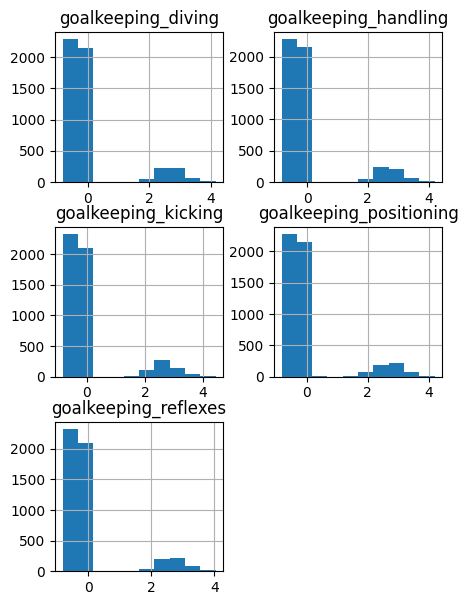

<Figure size 640x480 with 0 Axes>

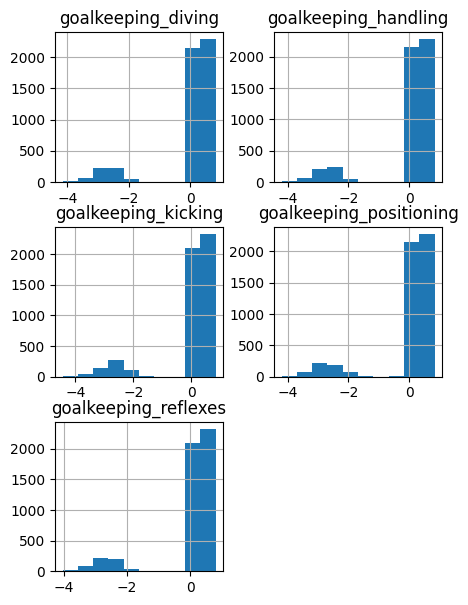

In [7]:
# Experiment with flipping the goalkeeper statistics 
X_transformed = pd.DataFrame(preprocesser_simple.fit_transform(features_X, regression_target_Y), 
                             columns=numerical_features_X)

goal = [col for col in X_transformed.columns if 'goalkeeping' in col]

plt.clf()
X_transformed[goal].hist(figsize=(5, 7))
plt.show()

X_transformed = pd.DataFrame(preprocesser_flip.fit_transform(features_X, regression_target_Y), 
                             columns=numerical_features_X)

goal = [col for col in X_transformed.columns if 'goalkeeping' in col]

plt.clf()
X_transformed[goal].hist(figsize=(5,7))
plt.show()


In [8]:
# Define the pipelines

regressor = SGDRegressor(random_state=0)

clf_naive = Pipeline(
    steps=[("preprocessor", preprocesser_naive_cat),
            ("regressor", regressor)]
)
clf = Pipeline(
    steps=[("preprocessor", preprocesser_simple),
            ("regressor", regressor)]
)
clf_flip = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", regressor)]
)
clf_pca = Pipeline(
    steps=[("preprocessor", preprocesser_pca),
            ("regressor", regressor)]
)


## Part B

### 4. Simple Baseline
A simple baseline that does not use any knowledge about the player could be the mean of the salary.

We will make use of the Dummy Classifier with the mean as the "best guess".

In [9]:
# Use dummy regression to mean as the baseline, and use it to compute the MAE.
dummy_regressor = DummyRegressor(strategy='mean')

# Run the pipeline using the Dummy classifier.
regressor_dummy = DummyRegressor()

clf_dummy = Pipeline(
    steps=[("preprocessor", preprocesser_ct),
            ("regressor", regressor_dummy)]
)

# Crossvalidation
# Score: MAE : ‘neg_mean_absolute_error’
# https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

K = 100

dummy_negative_mae = cross_val_score(clf_dummy, features_X, regression_target_Y, cv=KFold(K, shuffle=True, random_state=0), scoring='neg_mean_absolute_error')
dummy_mae = [-x for x in dummy_negative_mae]
dummy_mae_over_cv = sum(dummy_mae) / len(dummy_mae)

print(f'Dummy MAE over {K} folds is: {dummy_mae_over_cv:.3f}')

Dummy MAE over 100 folds is: 0.492


The above is clearly quite a large mean absolute error.

### 5. KNN and SGD Regressors

We train the KNN and SGD Regressors using their default parameters.
To estimate their performance fairly, we will use K-fold Crossvalidation (i.e. fit data on all but the test fold, test on the test fold, repeat and average score).

This should give us an accurate estimate of the generalisation error of the classifiers. To speed up, we can reduce to smaller K-fold crossvalidation when doing Grid Search.

There are in total four pipelines that we have tested. We will run all four, each on the SGD and KNN regressors.

### SGD:

In [10]:
# First compute all for SGD and then all for KNN

### SGD ###
regressor = SGDRegressor(random_state=0)

# Repeat the pipelines
clf_naive = Pipeline(
    steps=[("preprocessor", preprocesser_naive_cat),
            ("regressor", regressor)]
)
clf = Pipeline(
    steps=[("preprocessor", preprocesser_simple),
            ("regressor", regressor)]
)
clf_flip = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", regressor)]
)
clf_pca = Pipeline(
    steps=[("preprocessor", preprocesser_pca),
            ("regressor", regressor)]
)

# Will loop over pipelines
pipelines = [('simplest', clf_naive), ('standard', clf), ('flipped', clf_flip), ('pca', clf_pca)]

# Keep scores per pipeline
scores_sgd = {}

for (pipe_name, pipeline) in pipelines:
    # Fit using crossvalidation
    K = 100

    negative_mae = cross_val_score(pipeline, features_X, regression_target_Y, cv=KFold(K, shuffle=True, random_state=0), scoring='neg_mean_absolute_error')
    mae = [-x for x in negative_mae]
    mae_over_cv = sum(mae) / len(mae)

    scores_sgd[pipe_name] = mae_over_cv

print(scores_sgd)


{'simplest': np.float64(18558345918441.582), 'standard': np.float64(0.27636951879047755), 'flipped': np.float64(0.26661382057146665), 'pca': np.float64(0.2728708859551759)}


### KNN:

In [11]:
### KNN ###
regressor = KNeighborsRegressor()

# Repeat the pipelines
clf_naive = Pipeline(
    steps=[("preprocessor", preprocesser_naive_cat),
            ("regressor", regressor)]
)
clf = Pipeline(
    steps=[("preprocessor", preprocesser_simple),
            ("regressor", regressor)]
)
clf_flip = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", regressor)]
)
clf_pca = Pipeline(
    steps=[("preprocessor", preprocesser_pca),
            ("regressor", regressor)]
)

# Will loop over pipelines
pipelines = [('simplest', clf_naive), ('standard', clf), ('flipped', clf_flip), ('pca', clf_pca)]

# Keep scores per pipeline
scores_knn = {}

for (pipe_name, pipeline) in pipelines:
    # Fit using crossvalidation
    K = 100

    negative_mae = cross_val_score(pipeline, features_X, regression_target_Y, cv=KFold(K, shuffle=True, random_state=0), scoring='neg_mean_absolute_error')
    mae = [-x for x in negative_mae]
    mae_over_cv = sum(mae) / len(mae)

    scores_knn[pipe_name] = mae_over_cv

print(scores_knn)

{'simplest': np.float64(0.29162128680918287), 'standard': np.float64(0.28114426371400436), 'flipped': np.float64(0.25977810742068835), 'pca': np.float64(0.2593542264194005)}


### 6. Compare pipelines & Regressors

Here, we compare the combination of all pipelines and regressors on their default parameters. The goal of this comparison is to select the best performing pipeline, regardles of the regressor.

In [12]:
pipeline_performances = []

for pipeline_name in scores_sgd.keys():
    pipeline_performances.append((pipeline_name + '_SGD', scores_sgd[pipeline_name]))
    pipeline_performances.append((pipeline_name + '_KNN', scores_knn[pipeline_name]))

pipeline_performances.sort(key=lambda x: x[1])
for idx, perf in enumerate (pipeline_performances):
    print(f'{idx:5}: {perf[0]:20} {perf[1]:.4f}')

    0: pca_KNN              0.2594
    1: flipped_KNN          0.2598
    2: flipped_SGD          0.2666
    3: pca_SGD              0.2729
    4: standard_SGD         0.2764
    5: standard_KNN         0.2811
    6: simplest_KNN         0.2916
    7: simplest_SGD         18558345918441.5820


Above, we can see that the best performing pipeline-regressor combination is the pca-KNN. However, the PCA pipeline is underperforming on the SGD regressor. A pipeline that works well in both cases is the flipped pipeline, which we will select to use for further exercises.

### Visualise Pipeline & Regressor performances

<BarContainer object of 7 artists>

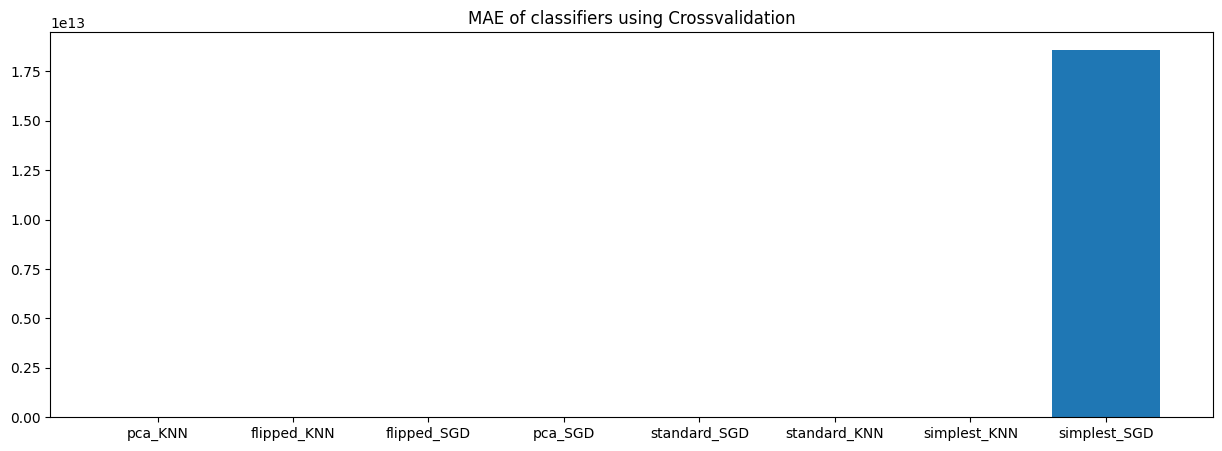

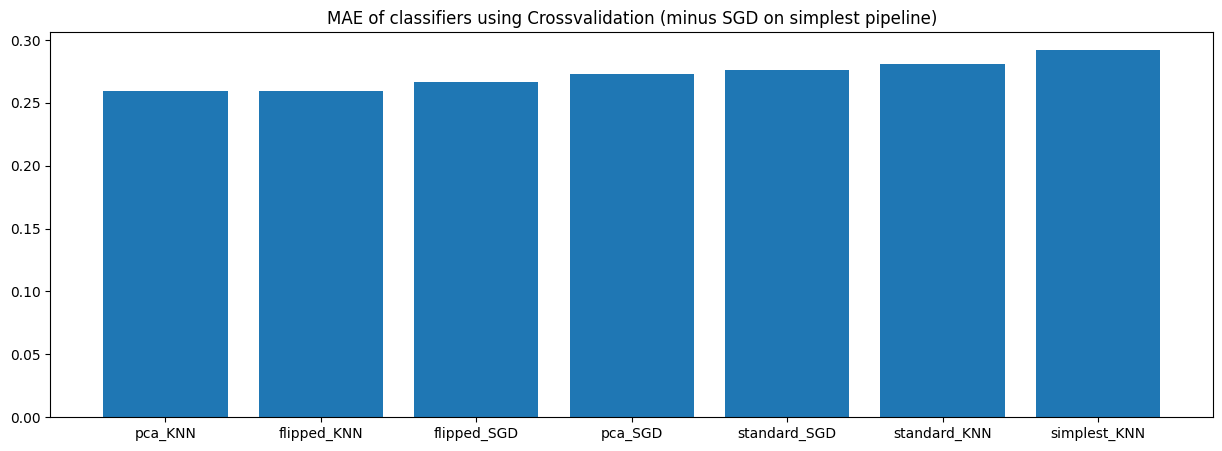

In [13]:
plt.figure(figsize=(15,5))
# Unusable (SGD too large)

plt.title('MAE of classifiers using Crossvalidation')
plt.bar([x[0] for x in pipeline_performances], [x[1] for x in pipeline_performances])

# Without SGD on simplest
plt.figure(figsize=(15,5))

plt.title('MAE of classifiers using Crossvalidation (minus SGD on simplest pipeline)')
plt.bar([x[0] for x in pipeline_performances[:-1]], [x[1] for x in pipeline_performances[:-1]])


### Extra: Compare the Dummy (mean) regressor across pipelines
Compare performance of the dummy classifier and the two other classifiers using the pipeline.
It essentially does not differ, as we expected.

<BarContainer object of 4 artists>

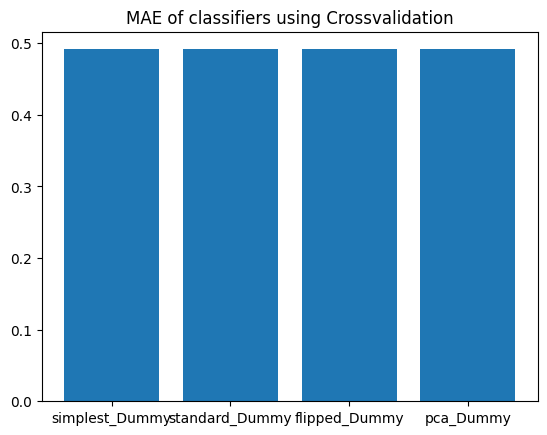

In [14]:
scores_dummy = {}

regressor = DummyRegressor(strategy='mean')

clf_naive = Pipeline(
    steps=[("preprocessor", preprocesser_naive_cat),
            ("regressor", regressor)]
)
clf = Pipeline(
    steps=[("preprocessor", preprocesser_simple),
            ("regressor", regressor)]
)
clf_flip = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", regressor)]
)
clf_pca = Pipeline(
    steps=[("preprocessor", preprocesser_pca),
            ("regressor", regressor)]
)

pipelines = [('simplest', clf_naive), ('standard', clf), ('flipped', clf_flip), ('pca', clf_pca)]
for (pipe_name, pipeline) in pipelines:
    # Fit using crossvalidation
    K = 100

    negative_mae = cross_val_score(pipeline, features_X, regression_target_Y, cv=KFold(K, shuffle=True, random_state=0), scoring='neg_mean_absolute_error')
    mae = [-x for x in negative_mae]
    mae_over_cv = sum(mae) / len(mae)

    scores_dummy[pipe_name] = mae_over_cv

dummy_performances = []

for pipeline_name in scores_sgd.keys():
    dummy_performances.append((pipeline_name + '_Dummy', scores_dummy[pipeline_name]))

plt.title('MAE of classifiers using Crossvalidation')
plt.bar([x[0] for x in dummy_performances], [x[1] for x in dummy_performances])

### 7. Autograder Results


In the autograder you will need to provide two things: 1) estimate of the MAE of your model on unseen data, 2) the predictions on the autograder data. For the autograder data we only provide the features and not the regression targets. Thus, you cannot compute the MAE on this data yourself - you need to estimate that with the data provided above. 

In [15]:
clf_sgd_flip = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", SGDRegressor(random_state=0))]
)
clf_knn_flip = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", KNeighborsRegressor())]
)

In [16]:
data_autograder = pd.read_csv('football_autograder.csv')
data_autograder.head()

,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_agility,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,27.0,190.0,78.0,b'England',70.0,71.0,52.0,42.0,75.0,60.0,...,57.0,67.0,61.0,72.0,68.0,15.0,8.0,12.0,13.0,15.0
1,19.0,183.0,76.0,b'Republic of Ireland',59.0,77.0,45.0,20.0,53.0,60.0,...,66.0,55.0,69.0,59.0,57.0,8.0,11.0,10.0,6.0,11.0
2,20.0,172.0,67.0,b'China PR',48.0,53.0,40.0,34.0,38.0,52.0,...,57.0,56.0,70.0,35.0,43.0,12.0,6.0,9.0,7.0,12.0
3,28.0,170.0,65.0,b'Brazil',76.0,76.0,73.0,76.0,52.0,72.0,...,89.0,70.0,88.0,50.0,48.0,12.0,7.0,12.0,10.0,7.0
4,28.0,186.0,74.0,b'England',65.0,67.0,18.0,19.0,15.0,25.0,...,32.0,57.0,57.0,14.0,17.0,66.0,64.0,66.0,63.0,68.0


In [17]:
# TODO Replace this with your own estimate of the MAE of your best model
estimate_MAE_on_new_data = scores_sgd['flipped']

# TODO Replace this with the predictions of your best model
# via e.g. prediction = model.predict(data_autograder)
# your predictions here should again be the $log_{10}(wage)$ of the football player, just as in the provided data. 
clf_sgd_flip.fit(features_X, regression_target_Y)
predictions_autograder_data = clf_sgd_flip.predict(X=data_autograder)

# Upload this file to the Vocareum autograder:
result = np.append(estimate_MAE_on_new_data, predictions_autograder_data)
pd.DataFrame(result).to_csv("baseSGDflipped.txt", index=False, header=False)

In [18]:
# TODO Replace this with your own estimate of the MAE of your best model
estimate_MAE_on_new_data = scores_knn['flipped']

# TODO Replace this with the predictions of your best model
# via e.g. prediction = model.predict(data_autograder)
# your predictions here should again be the $log_{10}(wage)$ of the football player, just as in the provided data. 
clf_knn_flip.fit(features_X, regression_target_Y)
predictions_autograder_data = clf_knn_flip.predict(X=data_autograder)

# Upload this file to the Vocareum autograder:
result = np.append(estimate_MAE_on_new_data, predictions_autograder_data)
pd.DataFrame(result).to_csv("baseKNNflipped.txt", index=False, header=False)

## Part C

### 8. Tuning KNN and SGD w/ GridSearch

#### KNN GridSearch Pipeline

In [19]:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
# Grid Search for KNN
knn_pipeline = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", KNeighborsRegressor())]
)
# Grid Search Implementation
knn_param_grid = {
    'regressor__n_neighbors': [i for i in range(1, 200, 2)],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__p': [1, 2, 3]
}
K = 100
cv = KFold(K, shuffle=True, random_state=0)

knn_gridsearch = GridSearchCV(estimator=knn_pipeline, 
                              param_grid=knn_param_grid,
                              scoring='neg_mean_absolute_error',
                              cv=cv,
                              n_jobs=-1 # parallel processing
                              )

#### SGD GridSearch Pipeline

In [ ]:
# Grid Search for SGD
sgd_pipeline = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", SGDRegressor(
                max_iter=5000,
                tol=1e-3,
                early_stopping=True,
                n_iter_no_change=5,
                validation_fraction=0.1,
                learning_rate="optimal",
                loss="huber",
                average=True,
                random_state=0
            ))]
)

sgd_param_grid = [
    # L1 / L2 penalties
    # Elastic Net penalty (needs l1_ratio)
    {
        "regressor__penalty": ["elasticnet"],
        "regressor__l1_ratio": [0.1, 0.25, 0.5, 0.75, 0.9],

        "regressor__alpha": np.logspace(-6, -1, 6),

        "regressor__learning_rate": ["optimal", "invscaling", "constant"],
        "regressor__eta0": [1e-4, 1e-3, 1e-2, 1e-1],
        "regressor__power_t": [0.25, 0.5, 0.75],

        "regressor__max_iter": [10000],
        "regressor__tol": [1e-4, 1e-3],

        "regressor__loss": [
            "huber",
        ],
        "regressor__epsilon": [0.01, 0.1, 0.5],
        "regressor__average": [True, False],
    }
]


cv = KFold(10, shuffle=True, random_state=0)

sgd_gridsearch = GridSearchCV(estimator=sgd_pipeline, 
                              param_grid=sgd_param_grid,
                              scoring='neg_mean_absolute_error',
                              cv=cv,
                              n_jobs=-1 # parallel processing
                              )

#### GridSearch Results

In [21]:
# KNN Gridsearch

model_score_results = []
for i in range(1): # 1 for now. Takes too long to execute..
    X_train, X_test, y_train, y_test = train_test_split(
        features_X, regression_target_Y, test_size=0.2
    )
    sgd_gridsearch.fit(X_train, y_train)
    print("SGD Best parameters found", sgd_gridsearch.best_params_)
    print(f"Best cross-validation score (MAE) {(-1) * sgd_gridsearch.best_score_:.4f}")
    
    knn_gridsearch.fit(X_train, y_train)
    print("\nKNNBest parameters found", knn_gridsearch.best_params_)
    print(f"Best cross-validation score: {(-1) * knn_gridsearch.best_score_:.4f} ")
    # multiply by (-1) since the orginal scoring function was negative MAE, and we are after positive MAE 

SGD Best parameters found {'regressor__alpha': 1e-06, 'regressor__average': True, 'regressor__eta0': 0.1, 'regressor__l1_ratio': 0.1, 'regressor__learning_rate': 'constant', 'regressor__loss': 'huber', 'regressor__penalty': 'elasticnet'}
Best cross-validation score (MAE) 0.2644


KeyboardInterrupt: 

RESULTS FROM OTHER ITERATIONS:

SGD Best parameters found {'regressor__alpha': 1e-06, 'regressor__average': True, 'regressor__eta0': 0.1, 'regressor__l1_ratio': 0.75, 'regressor__learning_rate': 'constant', 'regressor__penalty': 'elasticnet'}
Best cross-validation score (MAE) 0.2615

SGD Best parameters found {'regressor__alpha': 1e-06, 'regressor__average': True, 'regressor__eta0': 0.1, 'regressor__l1_ratio': 0.1, 'regressor__learning_rate': 'constant', 'regressor__penalty': 'elasticnet'}
Best cross-validation score (MAE) 0.2656

SGD Best parameters found {'regressor__alpha': 1e-06, 'regressor__average': True, 'regressor__eta0': 0.1, 'regressor__l1_ratio': 0.5, 'regressor__learning_rate': 'constant', 'regressor__penalty': 'elasticnet'}
Best cross-validation score (MAE) 0.2654

SGD Best parameters found {'regressor__alpha': 1e-06, 'regressor__average': True, 'regressor__eta0': 0.1, 'regressor__l1_ratio': 0.9, 'regressor__learning_rate': 'constant', 'regressor__penalty': 'elasticnet'}
Best cross-validation score (MAE) 0.2639

SGD Best parameters found {'regressor__alpha': 1e-06, 'regressor__average': True, 'regressor__eta0': 0.1, 'regressor__l1_ratio': 0.25, 'regressor__learning_rate': 'constant', 'regressor__penalty': 'elasticnet'}
Best cross-validation score (MAE) 0.2638

SGD Best parameters found {'regressor__alpha': 1e-05, 'regressor__average': True, 'regressor__eta0': 0.1, 'regressor__l1_ratio': 0.1, 'regressor__learning_rate': 'constant', 'regressor__penalty': 'elasticnet'}
Best cross-validation score (MAE) 0.2621

SGD Best parameters found {'regressor__alpha': 1e-06, 'regressor__average': True, 'regressor__eta0': 0.1, 'regressor__l1_ratio': 0.1, 'regressor__learning_rate': 'constant', 'regressor__penalty': 'elasticnet'}
Best cross-validation score (MAE) 0.2651

### 9. Training Curve

In [22]:
from sklearn.metrics import mean_absolute_error

regressor = SGDRegressor(
            alpha=0.001,
            average=False,
            epsilon=0.5,
            eta0=0.1,
            l1_ratio=0.25,
            learning_rate='invscaling',
            loss='huber',
            max_iter=10000,
            penalty='elasticnet',
            power_t=0.5,
            tol=0.0001
           )

clf_flip = Pipeline(
    steps=[("preprocessor", preprocesser_flip)]
)

data_X = preprocesser_flip.fit_transform(features_X, regression_target_Y)

# Classical train-test split
X_train, X_test, y_train, y_test = train_test_split(data_X, regression_target_Y, test_size=0.2, random_state=0)

# In range of epochs, plot a training curve
EPOCHS = 5000

losses = []
for epoch in range (EPOCHS):
    
    # Transform data

    # Fit
    regressor.partial_fit(X_train, y_train)

    # Test
    ypred = regressor.predict(X_test)

    # Get MAE
    loss = mean_absolute_error(y_true=y_test, y_pred=ypred)

    # Append to losses
    losses.append(loss)


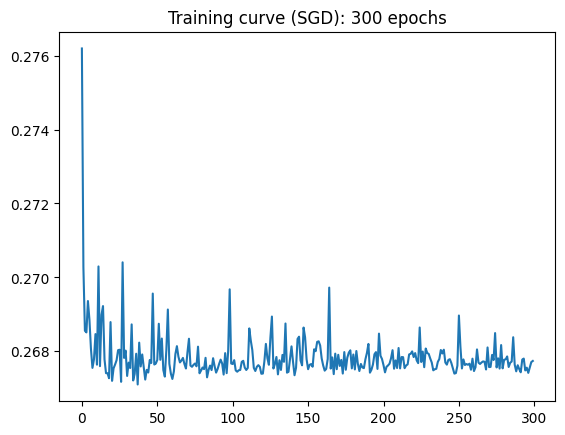

In [23]:
plt.title('Training curve (SGD): 300 epochs')
plt.plot(losses[:300])

### 10. Fairness of the performance estimate

### 11. Compare performance between before and after hyperparameter tuning

In [24]:
"""
SGD Best parameters found {'regressor__alpha': 0.001, 'regressor__average': False, 'regressor__eta0': 0.01, 'regressor__l1_ratio': 0.5, 'regressor__learning_rate': 'adaptive', 'regressor__penalty': 'elasticnet'}
Best cross-validation score (MAE) 0.2656

KNNBest parameters found {'regressor__n_neighbors': 13, 'regressor__p': 1, 'regressor__weights': 'distance'}
Best cross-validation score: 0.2506 

"""
clf_sgd_flip_tuned = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
           ("regressor", SGDRegressor(
            alpha=0.001,
            average=False,
            epsilon=0.5,
            eta0=0.1,
            l1_ratio=0.25,
            learning_rate='invscaling',
            loss='huber',
            max_iter=10000,
            penalty='elasticnet',
            power_t=0.5,
            tol=0.0001
           ))
        ]
)
clf_knn_flip_tuned = Pipeline(
    steps=[("preprocessor", preprocesser_flip),
            ("regressor", KNeighborsRegressor(
            n_neighbors=13,
            p=1,
            weights="distance"
        ))]
)


K=10
negative_mae = cross_val_score(clf_sgd_flip_tuned, features_X, regression_target_Y, cv=KFold(K, shuffle=True, random_state=0), scoring='neg_mean_absolute_error')
mae = [-x for x in negative_mae]
sgd_mae_over_cv = sum(mae) / len(mae)
print("SGD", sgd_mae_over_cv)

negative_mae = cross_val_score(clf_knn_flip_tuned, features_X, regression_target_Y, cv=KFold(K, shuffle=True, random_state=0), scoring='neg_mean_absolute_error')
mae = [-x for x in negative_mae]
knn_mae_over_cv = sum(mae) / len(mae)
print("KNN", knn_mae_over_cv)

#best_sgd_mae = sgd_gridsearch.best_score_ * (-1)
#best_knn_mae = knn_gridsearch.best_score_ * (-1)

#print(f"KNN: Best cross-validation score (MAE) {best_knn_mae}")
#print(f"SGD: Best cross-validation score (MAE) {best_sgd_mae}")

SGD 0.26325846678910086
KNN 0.24882212999364128


In [25]:
estimate_MAE_on_new_data = sgd_mae_over_cv

clf_sgd_flip_tuned.fit(features_X, regression_target_Y)
predictions_autograder_data = clf_sgd_flip_tuned.predict(X=data_autograder)

result = np.append(estimate_MAE_on_new_data, predictions_autograder_data)
pd.DataFrame(result).to_csv("bestSGDflipped.txt", index=False, header=False)

In [26]:
estimate_MAE_on_new_data = knn_mae_over_cv

clf_knn_flip_tuned.fit(features_X, regression_target_Y)
predictions_autograder_data = clf_knn_flip_tuned.predict(X=data_autograder)

result = np.append(estimate_MAE_on_new_data, predictions_autograder_data)
pd.DataFrame(result).to_csv("bestKNNflipped.txt", index=False, header=False)